<a href="https://colab.research.google.com/github/Anirudh2006-SRM/nvidia-sentimental-stock-analysis-/blob/main/nvidia_sentimental_stock_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import requests

# Specify the start and end dates
start_date = "2025-02-05"
end_date = datetime.now().strftime('%Y-%m-%d')

# Collect Nvidia stock data from the specified date range
nvidia_stock = yf.Ticker("NVDA")
stock_data = nvidia_stock.history(start=start_date, end=end_date)
stock_data.reset_index(inplace=True)
stock_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2025-02-05 00:00:00-05:00,121.726700,124.965812,120.726974,124.795860,262230800,0.0,0.0
1,2025-02-06 00:00:00-05:00,127.385171,128.734808,125.175776,128.644821,251483600,0.0,0.0
2,2025-02-07 00:00:00-05:00,129.184664,130.334343,124.965816,129.804489,228186300,0.0,0.0
3,2025-02-10 00:00:00-05:00,130.054419,134.963079,129.924464,133.533478,216989100,0.0,0.0
4,2025-02-11 00:00:00-05:00,132.543761,134.443236,130.984190,132.763702,178902400,0.0,0.0


In [3]:
stock_data

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2025-02-05 00:00:00-05:00,121.726700,124.965812,120.726974,124.795860,262230800,0.0,0.0
1,2025-02-06 00:00:00-05:00,127.385171,128.734808,125.175776,128.644821,251483600,0.0,0.0
2,2025-02-07 00:00:00-05:00,129.184664,130.334343,124.965816,129.804489,228186300,0.0,0.0
3,2025-02-10 00:00:00-05:00,130.054419,134.963079,129.924464,133.533478,216989100,0.0,0.0
4,2025-02-11 00:00:00-05:00,132.543761,134.443236,130.984190,132.763702,178902400,0.0,0.0
...,...,...,...,...,...,...,...,...
267,2026-03-02 00:00:00-05:00,175.009995,183.460007,174.639999,182.479996,209095300,0.0,0.0
268,2026-03-03 00:00:00-05:00,178.490005,180.899994,176.919998,180.050003,178099400,0.0,0.0
269,2026-03-04 00:00:00-05:00,180.440002,184.699997,180.059998,183.039993,177731200,0.0,0.0
270,2026-03-05 00:00:00-05:00,181.169998,184.059998,177.880005,183.339996,198779700,0.0,0.0


In [6]:
api_key = 'ad6d721e4bbd45beacb152f02c24a3e1'


url = 'https://newsapi.org/v2/everything'
params = {
    'q': 'Nvidia',
    'from': (datetime.now() - timedelta(days=28)).strftime('%Y-%m-%d'),  # Get articles from the last 30 days
    'sortBy': 'relevancy',
    'apiKey': api_key,
    'pageSize': 100,  # Maximum number of results per page
    'language': 'en'
}

# Make the request
response = requests.get(url, params=params)
data = response.json()

# Check for errors
if data['status'] != 'ok':
    raise Exception(f"NewsAPI error: {data['message']}")

# Extract articles
articles = data['articles']

# Convert to DataFrame
news_data = pd.DataFrame(articles)
news_data = news_data[['publishedAt', 'title']]
news_data.columns = ['date', 'headline']

In [7]:
news_data

,date,headline
0,2026-02-18T00:27:08Z,Meta’s new deal with Nvidia buys up millions o...
1,2026-03-04T22:30:48Z,The $100 Billion OpenAI-Nvidia Deal Is Not Hap...
2,2026-03-02T16:56:49Z,Nvidia’s spending $4 billion on photonics to s...
3,2026-02-26T02:05:12Z,‘Compute Equals Revenues’: Nvidia Needs Jensen...
4,2026-03-04T15:17:31Z,One of Tesla's biggest individual shareholders...
...,...,...
86,2026-02-24T20:40:00Z,Nvidia Just Sold Its Stake in Applied Digital ...
87,2026-03-02T16:10:38Z,Could Palantir Technologies Accidentally Kill ...
88,2026-02-24T19:11:11Z,"These Are the Top 5 Stocks to Own for 2026, Ac..."
89,2026-03-03T21:33:15Z,Meta is forming a new AI engineering org for i...


In [8]:
# Preprocess news headlines
nltk.download('punkt_tab')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    words = word_tokenize(text)
    words = [word for word in words if word.isalpha()]
    words = [word for word in words if word.lower() not in stop_words]
    return ' '.join(words)

news_data['cleaned_headline'] = news_data['headline'].apply(preprocess_text)

# Perform sentiment analysis
analyzer = SentimentIntensityAnalyzer()

def get_sentiment_score(text):
    score = analyzer.polarity_scores(text)
    return score['compound']

news_data['sentiment_score'] = news_data['cleaned_headline'].apply(get_sentiment_score)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [9]:
news_data

,date,headline,cleaned_headline,sentiment_score
0,2026-02-18T00:27:08Z,Meta’s new deal with Nvidia buys up millions o...,Meta new deal Nvidia buys millions AI chips,0.0000
1,2026-03-04T22:30:48Z,The $100 Billion OpenAI-Nvidia Deal Is Not Hap...,Billion Deal Happening,0.0000
2,2026-03-02T16:56:49Z,Nvidia’s spending $4 billion on photonics to s...,Nvidia spending billion photonics stay ahead c...,0.0000
3,2026-02-26T02:05:12Z,‘Compute Equals Revenues’: Nvidia Needs Jensen...,Compute Equals Revenues Nvidia Needs Jensen Hu...,0.4215
4,2026-03-04T15:17:31Z,One of Tesla's biggest individual shareholders...,One Tesla biggest individual shareholders says...,0.2960
...,...,...,...,...
86,2026-02-24T20:40:00Z,Nvidia Just Sold Its Stake in Applied Digital ...,Nvidia Sold Stake Applied Digital Arm Holdings...,0.4767
87,2026-03-02T16:10:38Z,Could Palantir Technologies Accidentally Kill ...,Could Palantir Technologies Accidentally Kill ...,-0.7964
88,2026-02-24T19:11:11Z,"These Are the Top 5 Stocks to Own for 2026, Ac...",Top Stocks According ChatGPT,0.2023
89,2026-03-03T21:33:15Z,Meta is forming a new AI engineering org for i...,Meta forming new AI engineering org superintel...,0.0000


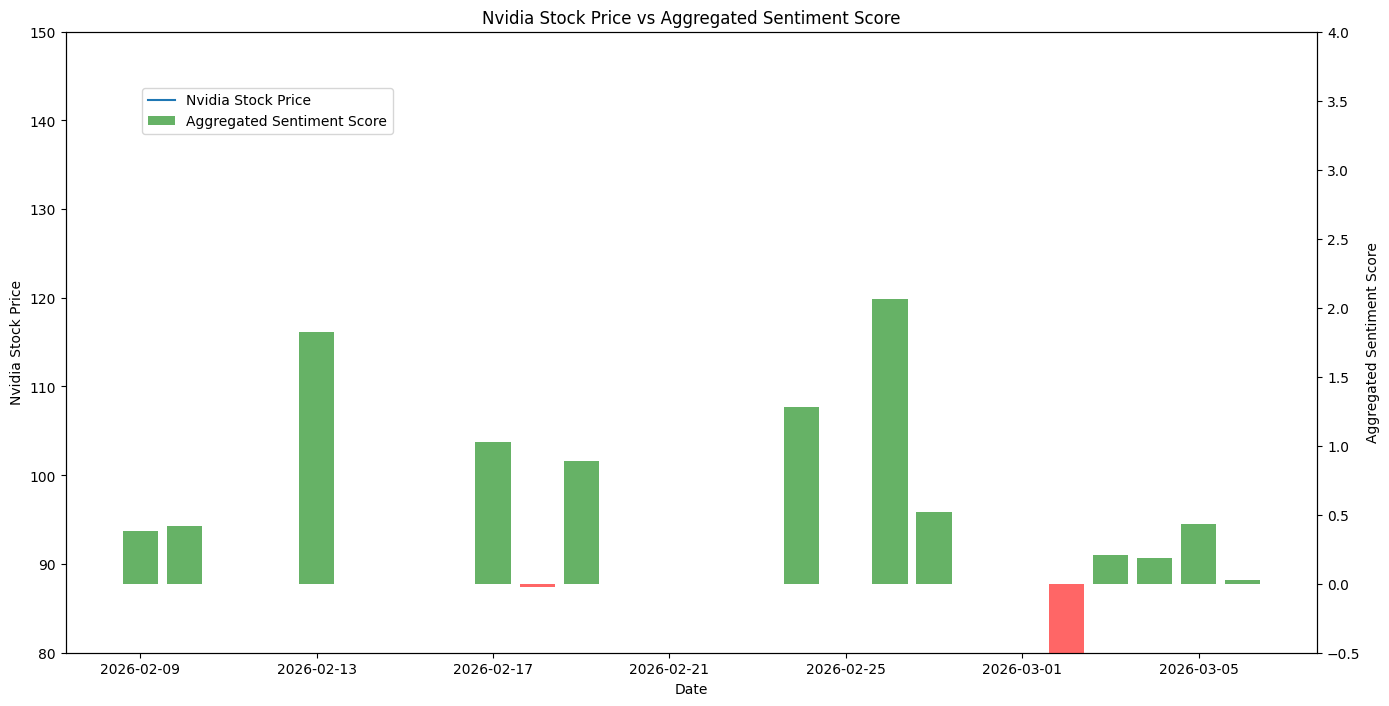

In [10]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment_score(text):
    score = analyzer.polarity_scores(text)
    return score['compound']

news_data['sentiment_score'] = news_data['cleaned_headline'].apply(get_sentiment_score)

# Convert dates to datetime format
news_data['date'] = pd.to_datetime(news_data['date']).dt.date
stock_data['Date'] = pd.to_datetime(stock_data['Date']).dt.date

# Aggregate sentiment scores by date
aggregated_sentiment = news_data.groupby('date')['sentiment_score'].sum().reset_index()

# Merge stock data with aggregated sentiment scores
combined_data = pd.merge(stock_data, aggregated_sentiment, left_on='Date', right_on='date', how='inner')

# Visualize the data with a secondary y-axis and bar plot for aggregated sentiment scores
fig, ax1 = plt.subplots(figsize=(14, 7))

ax1.set_xlabel('Date')
ax1.set_ylabel('Nvidia Stock Price')
ax1.plot(combined_data['Date'], combined_data['Close'], label='Nvidia Stock Price')
ax1.tick_params(axis='y')
ax1.set_ylim(80, 150)  # Set the left y-axis range

ax2 = ax1.twinx()  # Instantiate a second axes that shares the same x-axis
ax2.set_ylabel('Aggregated Sentiment Score')

# Use different colors for positive and negative bar values
colors = ['green' if val >= 0 else 'red' for val in combined_data['sentiment_score']]
ax2.bar(combined_data['Date'], combined_data['sentiment_score'], label='Aggregated Sentiment Score', color=colors, alpha=0.6)
ax2.tick_params(axis='y')
ax2.set_ylim(-0.5, 4)  # Set the right y-axis range

fig.tight_layout()
plt.title('Nvidia Stock Price vs Aggregated Sentiment Score')
fig.legend(loc='upper left', bbox_to_anchor=(0.1,0.9))
plt.show()